# 05 - Isolation of critical stations

A high betweenness score tells us that many shortest paths in the graph pass through a station. It does not tell us whether there is another physical stop nearby. We want to add that spatial context and separate structurally important stations with a nearby alternative from structurally important stations that are geographically isolated.

For a working rule, we define `critical` as betweenness at or above the 90th percentile and `isolated` as having no other graph station within 300 m. A haversine `BallTree` gives the nearest-neighbor distance for every station without constructing a full distance matrix. The result is a spatial screen on the centrality ranking, not proof that a nearby stop can replace the same service.

**Question for this notebook:** *Among the top-decile betweenness stations, how many have no other graph stop within our 300 m walking-distance threshold?*

### Input
- `outputs/nb/04_centrality_analysis/tables/stop_metrics.csv` - one row per graph node, with `stop_id`, `stop_name`, latitude, longitude, and betweenness centrality. (Produced by notebook `04` - this notebook does not recompute centrality.)

### Output (all under `outputs/nb/05_critical_station_isolation/`)
- `tables/critical_isolation.csv` - every critical station, its distance to the nearest alternative station, and an `is_isolated` flag.
- `tables/isolation_summary.csv` - the distance-band counts behind the main figure.
- `figures/critical_isolation.png` - critical stations grouped by distance to the nearest alternative, in green (within threshold) versus red (outside threshold).
- `figures/top_isolated_critical_stops.png` - the isolated single stations with the highest betweenness, labeled by name.

The word `alternative` below means only another graph stop close in straight-line distance. We do not test shared routes, direction, frequency, hours, barriers, or walking paths. Calling every nearby stop replaceable is generous, so the count beyond 300 m should be treated as a lower-bound screen for service-level isolation, not a complete operational answer.

## 1. Setting up the working environment

We start with the shared environment helper. It searches upward for `israel-public-transportation`, or clones the project into `/content` for a fresh Colab session, then changes to the repository root. `_ensure()` installs only missing imports, and the cell defines `REPO`, `DATA`, and `OUT` for all paths below.

`OUT` is the common notebook-output root; this stage creates and uses its own subfolder later.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Libraries

We do not need NetworkX here because notebook 04 already reduced the graph measures to one row per station. We import pandas for that table, NumPy for radian conversion and arrays, Matplotlib for figures, and `sklearn.neighbors.BallTree` for nearest-neighbor search.

With about 30 thousand stations, an all-pairs matrix would contain roughly $9 \times 10^8$ distances and need several gigabytes. The tree avoids materializing that matrix and answers all nearest-other-stop queries in a few seconds.

In [2]:
_ensure("numpy", "pandas", "matplotlib", "scikit-learn")

import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

print("numpy", np.__version__, "| pandas", pd.__version__)

Installing missing packages: scikit-learn
Using interpreter: /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
numpy 2.5.1 | pandas 3.0.5


## 3. Showing Hebrew text in matplotlib

The ranked chart labels stations in Hebrew. This Matplotlib build displays raw logical-order Hebrew correctly, so we leave `fix_he()` as a no-op, select a font with Hebrew glyphs, and remove any stale bidi text patch left in the current kernel. Pre-reordering here would reverse the label twice. We also use plain numeric formatting without scientific offsets.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove a bidi patch if the current kernel contains one, so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Stage folders and analysis parameters

This cell creates the stage's `tables` and `figures` folders and sets the definitions used throughout the analysis:


| Constant | Value | Meaning |
| --- | --- | --- |
| `CRITICAL_QUANTILE` | `0.90` | Our working `critical` cutoff: betweenness at or above the 90th percentile. |
| `WALK_M` | `300` | Our spatial alternative cutoff; 300 m is roughly a four-minute walk at ordinary walking speed. |
| `EARTH_M` | `6371000` | Mean Earth radius used to convert angular haversine results to meters. |
| `TOP_N_NAMED` | `15` | Number of isolated critical stations shown in the named ranking. |

The threshold values are assumptions we can vary, not values estimated from the data. The spatial search itself is inexpensive and introduces no sampling; uncertainty enters through the sampled betweenness input and through what we mean by a usable alternative.

In [4]:
STAGE = OUT / "05_critical_station_isolation"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

CRITICAL_QUANTILE = 0.90      # critical = top 10% betweenness
WALK_M = 300.0                # walking distance to an acceptable alternative stop (metres)
EARTH_M = 6371000.0           # mean Earth radius (metres)
TOP_N_NAMED = 15              # how many isolated stops to name in the second figure

print("Stage folder:", STAGE)

Stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/05_critical_station_isolation


## 5. Loading the centrality metrics from stage 04

We load `stop_metrics.csv` from notebook 04 so we do not recompute betweenness. The cell searches the stage directory, checks required fields, and stops clearly if the metrics file is unavailable.

We normalize supported column variants such as `stop_lat`/`lat` and `approx_betweenness`/`betweenness`, convert coordinates and scores to numeric values, and remove rows without usable coordinates. Those rows cannot enter the nearest-neighbor calculation, so we print the dropped count and retain one row per `stop_id`.

In [5]:
CENTRALITY_STAGE = OUT / "04_centrality_analysis"
metrics_path = CENTRALITY_STAGE / "tables" / "stop_metrics.csv"

if not metrics_path.exists():
    # tolerate a slightly different stage folder name for the centrality notebook
    candidates = sorted(OUT.glob("*centrality*/tables/stop_metrics.csv"))
    if candidates:
        metrics_path = candidates[0]
    else:
        raise FileNotFoundError(
            f"{metrics_path} missing - run notebook 04 (centrality analysis) first.")

raw = pd.read_csv(metrics_path, encoding="utf-8-sig")

# Normalise column names so either naming convention works.
RENAME = {
    "stop_lat": "lat",
    "stop_lon": "lon",
    "approx_betweenness": "betweenness",
    "betweenness_centrality": "betweenness",
}
raw = raw.rename(columns={k: v for k, v in RENAME.items()
                          if k in raw.columns and v not in raw.columns})

required = {"stop_id", "lat", "lon", "betweenness"}
missing_cols = required - set(raw.columns)
if missing_cols:
    raise KeyError(
        f"{metrics_path} is missing column(s) {sorted(missing_cols)}. "
        f"Found: {sorted(raw.columns)}")

if "stop_name" not in raw.columns:
    raw["stop_name"] = ""

metrics = raw.dropna(subset=["lat", "lon", "betweenness"]).reset_index(drop=True)

print(f"Loaded  : {metrics_path}")
print(f"Stops   : {len(raw):,} rows -> {len(metrics):,} usable "
      f"({len(raw) - len(metrics):,} dropped for missing coordinates/betweenness)")
metrics[["stop_id", "stop_name", "lat", "lon", "betweenness"]].head()

Loaded  : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables/stop_metrics.csv
Stops   : 30,463 rows -> 30,463 usable (0 dropped for missing coordinates/betweenness)


,stop_id,stop_name,lat,lon,betweenness
0,13103,קניון עזריאלי/דרך מנחם בגין,32.074592,34.790584,0.000828
1,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,0.016613
2,10716,צומת רמות/גולדה,31.808253,35.204001,0.010076
3,12910,דרך נמיר/יהודה המכבי,32.095376,34.794137,0.001347
4,13358,סמינר הקיבוצים/דרך נמיר,32.101886,34.792779,0.002775


## 6. Distance to the nearest alternative station (haversine BallTree)

For every station, we calculate great-circle distance to the nearest *other* station:

1. We convert latitude and longitude to radians because the BallTree's haversine metric consumes radians and returns angular distance.
2. We build the tree over the coordinate array so each query can prune distant branches rather than scanning all nodes.
3. We query `k=2` because result 0 is the station itself; result 1 is the closest other row.
4. We multiply angular distance by `EARTH_M` and store both the nearest station index/ID and `nearest_alt_m`.

Two different stop IDs can have identical coordinates, so zero meters is possible and counts as a colocated alternative under this rule. We print distance quantiles and inspect the closest pairs to catch unit or coordinate-order mistakes.

In [6]:
coords = np.radians(metrics[["lat", "lon"]].to_numpy(dtype=float))

tree = BallTree(coords, metric="haversine")
dist, _ = tree.query(coords, k=2)          # k=2: the stop itself + its nearest neighbour
metrics["nearest_alt_m"] = dist[:, 1] * EARTH_M

print("Distance to nearest other stop (metres), across all graph stops:")
print(metrics["nearest_alt_m"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).round(1))

Distance to nearest other stop (metres), across all graph stops:
count    30463.0
mean       107.8
std        200.9
min          0.0
25%         36.9
50%         79.4
75%        124.1
90%        184.7
99%        684.2
max      10540.2
Name: nearest_alt_m, dtype: float64


## 7. Splitting the critical stations: replaceable versus isolated

We calculate the betweenness quantile from all usable metric rows and select values at or above it. Within that selected set, `is_isolated` is true when `nearest_alt_m > WALK_M`. This is exactly our working spatial classification; it does not yet say that a within-threshold stop carries equivalent service.

For the summary we split distances into `0-100`, `100-300`, `300-500`, `500-1000`, and `>1000 m`. We use right-closed bins so a value exactly equal to 300 m remains in the within-threshold band, matching the strict `> 300` isolation test. The cell prints the cutoff, selected count, isolated share, and band totals so we can check that the categories add back to the critical set.

In [7]:
threshold = metrics["betweenness"].quantile(CRITICAL_QUANTILE)
critical = metrics[metrics["betweenness"] >= threshold].copy()
critical["is_isolated"] = critical["nearest_alt_m"] > WALK_M

n_crit = len(critical)
n_isolated = int(critical["is_isolated"].sum())
n_covered = n_crit - n_isolated

print(f"Betweenness threshold (q={CRITICAL_QUANTILE:.2f}) : {threshold:.8f}")
print(f"Critical stops (top 10% betweenness)   : {n_crit:,}")
print(f"  with an alternative within {WALK_M:.0f} m    : {n_covered:,} "
      f"({100 * n_covered / n_crit:.1f}%)")
print(f"  no nearby alternative within 300 m    : {n_isolated:,} "
      f"({100 * n_isolated / n_crit:.1f}%)")

Betweenness threshold (q=0.90) : 0.00058890
Critical stops (top 10% betweenness)   : 3,047
  with an alternative within 300 m    : 2,991 (98.2%)
  no nearby alternative within 300 m    : 56 (1.8%)


## 8. Saving the tables

We save two tables:

- `critical_isolation.csv` contains every selected station, nearest alternative ID/name/distance, and the isolation flag, sorted by betweenness.
- `isolation_summary.csv` contains the five plotted distance bands with counts, shares, and the within/beyond-threshold group.

Both use `utf-8-sig` so Hebrew names open correctly in spreadsheet software. The printed paths and file sizes confirm the save completed.

In [8]:
BINS = [0, 100, 300, 500, 1000, np.inf]
BAND_LABELS = ["< 100 m", "100-300 m", "300-500 m", "500-1000 m", "> 1 km"]

critical["distance_band"] = pd.cut(critical["nearest_alt_m"], bins=BINS,
                                   labels=BAND_LABELS, right=True, include_lowest=True)

critical_sorted = critical.sort_values("betweenness", ascending=False)
critical_path = TABLES / "critical_isolation.csv"
critical_sorted.to_csv(critical_path, index=False, encoding="utf-8-sig")

band_counts = critical["distance_band"].value_counts().reindex(BAND_LABELS).fillna(0).astype(int)
summary = pd.DataFrame({
    "distance_band": BAND_LABELS,
    "n_critical_stops": band_counts.to_numpy(),
    "share_pct": (100 * band_counts.to_numpy() / n_crit).round(2),
    "verdict": ["substitutable", "substitutable", "isolated", "isolated", "isolated"],
})
summary_path = TABLES / "isolation_summary.csv"
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("wrote", critical_path)
print("wrote", summary_path)
summary

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/05_critical_station_isolation/tables/critical_isolation.csv
wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/05_critical_station_isolation/tables/isolation_summary.csv


,distance_band,n_critical_stops,share_pct,verdict
0,< 100 m,1749,57.40,substitutable
1,100-300 m,1242,40.76,substitutable
2,300-500 m,35,1.15,isolated
3,500-1000 m,12,0.39,isolated
4,> 1 km,9,0.30,isolated


## 9. The main figure - does the critical station have a walkable alternative?

This figure plots the distance-band summary calculated above. Each bar counts critical stations whose nearest other graph stop falls in that range. We color the two bands at or below 300 m green and the three bands above 300 m red, matching the exact threshold used for `is_isolated`.

We annotate each bar with both count and percent and draw a dashed divider at the threshold boundary. The chart is a view of spatial proximity only, so the legend says `within threshold` rather than claiming every green station is operationally replaceable.

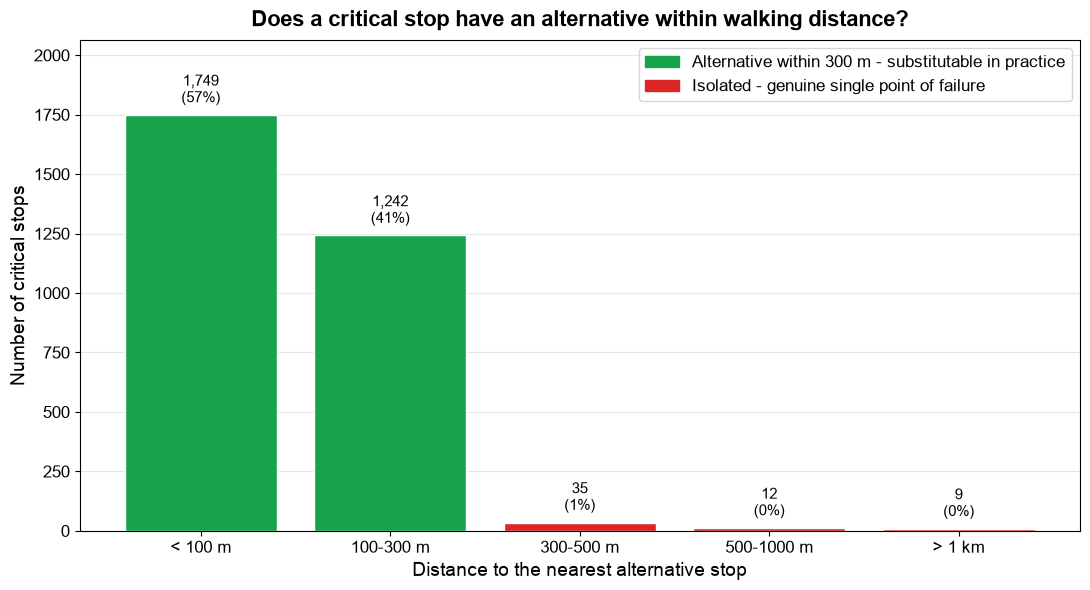

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/05_critical_station_isolation/figures/critical_isolation.png


In [9]:
counts = band_counts.to_numpy()
colors = ["#16a34a", "#16a34a", "#dc2626", "#dc2626", "#dc2626"]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(BAND_LABELS, counts, color=colors, edgecolor="white")

offset = max(counts.max() * 0.02, 1)
for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
            f"{v:,}\n({100 * v / n_crit:.0f}%)", ha="center", va="bottom", fontsize=11)

ax.set_xlabel("Distance to the nearest alternative stop", fontsize=14)
ax.set_ylabel("Number of critical stops", fontsize=14)
ax.set_title("Does a critical stop have an alternative within walking distance?",
             fontsize=16, fontweight="bold", pad=10)
ax.set_ylim(0, counts.max() * 1.18)
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#16a34a", label=f"Alternative within {WALK_M:.0f} m - substitutable in practice"),
    Patch(color="#dc2626", label="No other graph stop within 300 m"),
], fontsize=12, loc="upper right")

plt.tight_layout()
fig_path = FIGURES / "critical_isolation.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print("wrote", fig_path)

## 10. Which isolated stations matter most?

The distance-band chart gives a total but not a shortlist. Here we take the isolated critical rows, sort them by betweenness, and plot the top `TOP_N_NAMED` with their station names. These are the stations where high sampled shortest-path load and a beyond-threshold nearest stop occur together.

Bar length represents approximate betweenness, while the annotation gives nearest-stop distance, so both parts of our filter remain visible. We use explicit y positions to avoid merging duplicate Hebrew names and fall back to `stop_id` when a name is blank. This list is a starting point for checking actual routes and access, not an automatic intervention ranking.

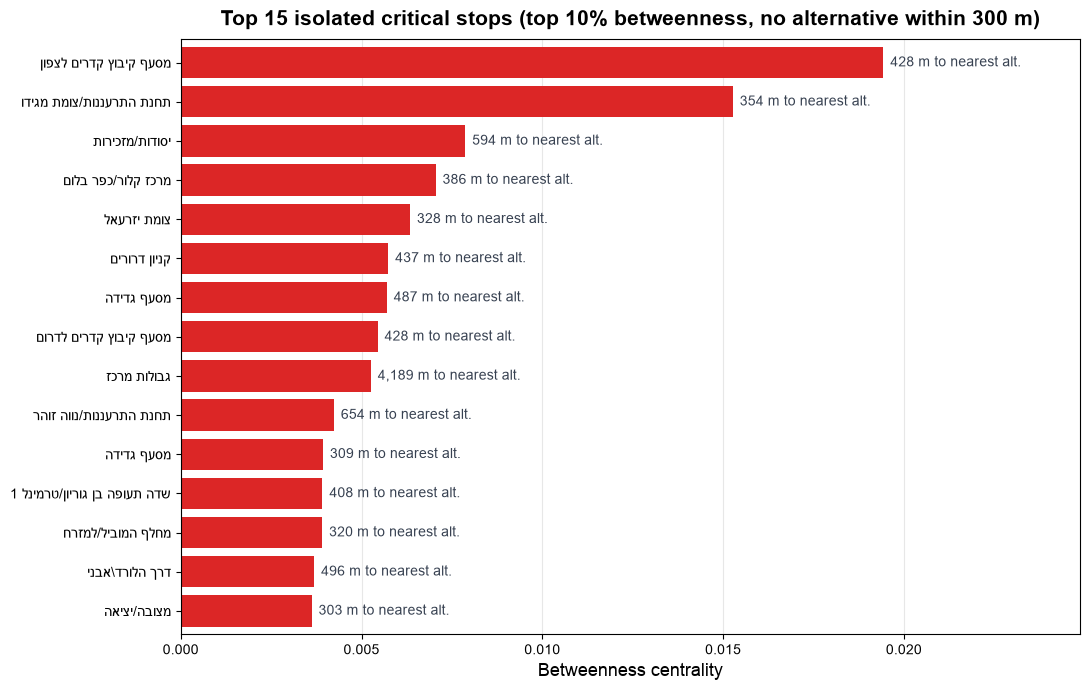

wrote /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/05_critical_station_isolation/figures/top_isolated_critical_stops.png


In [10]:
isolated = critical_sorted[critical_sorted["is_isolated"]].copy()

if isolated.empty:
    print("No isolated critical stops found - nothing to plot.")
else:
    top = isolated.head(TOP_N_NAMED).copy()
    top["label"] = (top["stop_name"].fillna("").astype(str).str.strip()
                    .where(lambda s: s != "", top["stop_id"].astype(str)))
    top = top.sort_values("betweenness").reset_index(drop=True)   # smallest at the bottom of a barh

    fig, ax = plt.subplots(figsize=(11, 7))
    # Use numeric y-positions (not the names) so two stops that share a name do not
    # collapse onto one bar and leave an orphaned distance label floating at the top.
    ypos = list(range(len(top)))
    ax.barh(ypos, top["betweenness"], color="#dc2626")
    ax.set_yticks(ypos)
    ax.set_yticklabels(top["label"])

    span = top["betweenness"].max()
    for y, (btw, d) in enumerate(zip(top["betweenness"], top["nearest_alt_m"])):
        ax.text(btw + span * 0.01, y, f"{d:,.0f} m to nearest alt.",
                va="center", fontsize=10, color="#374151")

    ax.set_xlim(0, span * 1.28)
    ax.set_ylim(-0.6, len(top) - 0.4)
    ax.set_xlabel("Betweenness centrality", fontsize=13)
    ax.set_title(f"Top {len(top)} isolated critical stops "
                 f"(top 10% betweenness, no alternative within {WALK_M:.0f} m)",
                 fontsize=15, fontweight="bold", pad=10)
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    fig2_path = FIGURES / "top_isolated_critical_stops.png"
    plt.savefig(fig2_path, dpi=150)
    plt.show()
    print("wrote", fig2_path)

    display_cols = [c for c in ["stop_id", "stop_name", "betweenness", "nearest_alt_m"]
                    if c in isolated.columns]
    isolated[display_cols].head(TOP_N_NAMED).round(6)

## 11. Limits of this spatial screen

1. The alternative test is spatial only. A stop within 300 m can serve different routes, directions, frequencies, or hours. Treating it as a substitute therefore tends to overstate operational replaceability. A stronger follow-up would require shared routes or compare reachable destinations and service frequency.

2. The BallTree contains graph nodes, not every raw GTFS stop row. A nearby stop that never participated in a constructed edge is invisible here, which can make a station look more isolated. This bias points in the opposite direction from the generous substitute assumption, and we do not quantify the balance between them.

3. Haversine is straight-line distance, not a walkable-path distance. Roads, rail lines, fences, slopes, and crossings can make the actual walking route longer, again making some within-threshold pairs less substitutable than they appear.

4. Betweenness is estimated from sampled sources. Membership near the 90th-percentile cutoff can change with the seed, as measured in notebook 04, so stations just above and below the threshold form an uncertainty band rather than two perfectly distinct groups.

5. The 300 m and top-decile cutoffs are choices, not fitted results. A sensitivity run over several walking distances and centrality quantiles would show how much the isolated share depends on them.

## 12. Conclusions

This notebook narrows a centrality ranking with one additional question: is there another graph stop nearby? The p90 rule selects 3,047 stations in this run. Of those, 2,991 (98.16%) have another graph stop within 300 m, while 56 (1.84%) are beyond the threshold: 35 at 300–500 m, 12 at 500–1,000 m, and 9 beyond 1 km. The selected set is therefore not spatially uniform, but the beyond-threshold group is much smaller than the full centrality shortlist.

`critical_isolation.csv` is the useful result because it keeps the selected stop, nearest alternative, distance, betweenness, and flag together. The named chart highlights the strongest isolated candidates under these definitions, but we still need route and access information before calling any nearby station a real substitute or recommending a particular intervention.

The isolated count is best treated as a lower-bound service screen because the main simplifications make substitution too easy: any nearby graph stop qualifies, even if its service is unrelated, and straight-line distance ignores barriers. Restricting the tree to graph nodes can push the other way by omitting inactive nearby GTFS records, but that effect is not measured here.

The classification also depends on two thresholds and a sampled centrality estimate. A station near the p90 boundary or close to 300 m can change category under reasonable settings. The conclusion is therefore not that green means safe and red means definitively irreplaceable; it is that spatial proximity helps reduce the centrality list to a smaller set worth checking with shared routes, service frequency, and real walking paths. The BallTree makes that first screen computationally cheap without an all-pairs distance matrix.